In [1]:

import os
import json
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
from torch.utils.data import Dataset

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    average_precision_score,
)

SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)
import os




/data1/rachit/.conda/envs/cond/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATA_PATH="../../transactions/card_transaction.v1.csv"
df = pd.read_csv(DATA_PATH)

In [3]:

df["Amount"] = df["Amount"].replace('[\$,]', '', regex=True).astype(float)

df["Hour"] = pd.to_datetime(df["Time"], errors="coerce").dt.hour

df["Use Chip"] = df["Use Chip"].map({"Yes": 1, "No": 0}).fillna(0)

df["Errors?"] = (df["Errors?"] != "None").astype(int)

df["Zip"] = pd.to_numeric(df["Zip"], errors="coerce")

df["Time"] = pd.to_numeric(df["Time"], errors="coerce")

df["Hour"] = (df["Time"] // 3600) % 24
df["Is Fraud?"] = df["Is Fraud?"].map({"Yes": 1, "No": 0})

df = df.fillna(0)

# print(df.dtypes)
# print(df.head())

/tmp/ipykernel_1013605/3282332532.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Hour"] = pd.to_datetime(df["Time"], errors="coerce").dt.hour


In [4]:
df["Merchant City"] = df["Merchant City"].astype(str)
df["Merchant State"] = df["Merchant State"].astype(str)

In [5]:
print(df.dtypes)
print(df.head())

User                int64
Card                int64
Year                int64
Month               int64
Day                 int64
Time              float64
Amount            float64
Use Chip          float64
Merchant Name       int64
Merchant City      object
Merchant State     object
Zip               float64
MCC                 int64
Errors?             int64
Is Fraud?           int64
Hour              float64
dtype: object
   User  Card  Year  Month  Day  Time  Amount  Use Chip        Merchant Name  \
0     0     0  2002      9    1   0.0  134.09       0.0  3527213246127876953   
1     0     0  2002      9    1   0.0   38.48       0.0  -727612092139916043   
2     0     0  2002      9    2   0.0  120.34       0.0  -727612092139916043   
3     0     0  2002      9    2   0.0  128.95       0.0  3414527459579106770   
4     0     0  2002      9    3   0.0  104.71       0.0  5817218446178736267   

   Merchant City Merchant State      Zip   MCC  Errors?  Is Fraud?  Hour  
0       La Ver

## Run form here

In [6]:

from dotenv import load_dotenv
import os
import google.generativeai as genai

load_dotenv()

genai.configure(api_key=os.getenv("GEMINI_API_KEY"))

/data1/rachit/.conda/envs/cond/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/tmp/ipykernel_1013605/2009901296.py:3: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


In [7]:
for m in genai.list_models():
    print(m.name, "->", m.supported_generation_methods)

models/gemini-2.5-flash -> ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
models/gemini-2.5-pro -> ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
models/gemini-2.0-flash -> ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
models/gemini-2.0-flash-001 -> ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
models/gemini-2.0-flash-lite-001 -> ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
models/gemini-2.0-flash-lite -> ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
models/gemini-2.5-flash-preview-tts -> ['countTokens', 'generateContent']
models/gemini-2.5-pro-preview-tts -> ['countTokens', 'generateContent', 'batchGenerateContent']
models/gemma-3-1b-it -> ['generateContent', 'countTokens']
models/gemma-3-4b-it -> ['generateContent', 'countTokens']
models/gemma-3-12b-it -> ['generateContent

In [8]:
model_llm = genai.GenerativeModel("models/gemini-flash-latest")

In [9]:
PROMPT = """
==============================
DATA SUMMARY
==============================

- Number of users: 2000
- Transactions span: multiple years (1991–2020)
- Amount has high variability (~100K unique values)
- Merchant Name is high-cardinality (~100K unique)
- Merchant City is high-cardinality (~13K)
- Merchant State includes global locations (223 unique)
- Errors column contains multiple error types (including combinations)
- Fraud label is binary (Yes/No)

==============================
VALUE DISTRIBUTION INSIGHTS
==============================

Use Chip:
- Swipe Transaction
- Online Transaction
- Chip Transaction

Errors?:
- NaN (no error)
- Technical Glitch
- Insufficient Balance
- Bad PIN
- Bad CVV
- Bad Zipcode
- Combinations of above errors

Merchant State:
- Mix of US states and international locations

Is Fraud:
- Yes / No

==============================
SAMPLE DATA (STRUCTURE)
==============================

Each row represents a transaction:

User=0, Card=0, Year=2002, Month=9, Day=1, Time=06:21,
Amount=$134.09, Use Chip=Swipe Transaction,
Merchant Name=high-cardinality ID,
Merchant City=La Verne, Merchant State=CA,
Zip=91750, MCC=5300, Errors?=NaN, Is Fraud=No

==============================
PREPROCESSING & MISSING VALUE HANDLING
==============================

Before feature computation, assume the following preprocessing has been applied:

1. Amount:
   - Remove "$" and convert to float
   - Missing values (if any) → fill with median Amount

2. Time:
   - Convert "HH:MM" → Hour (0–23)
   - Missing values → fill with mode Hour

3. Use Chip:
   - Encode as:
       Swipe Transaction → 0
       Chip Transaction → 1
       Online Transaction → 2
   - Missing values → fill with most frequent category

4. Errors?:
   - NaN → 0 (no error)
   - Any error string → 1 (error present)

5. Merchant City / Merchant State:
   - Missing values → fill with "Unknown"

6. Zip:
   - Missing values → fill with median Zip

7. MCC:
   - Missing values → fill with mode MCC

8. Is Fraud:
   - Yes → 1, No → 0
   - MUST NOT be used for feature generation

After preprocessing, the following cleaned columns are available:

- Amount (float)
- Hour (int)
- Use Chip (int)
- Errors? (int)
- MCC (int)
- Merchant City (string)
- Merchant State (string)
- Zip (float)


==============================
IMPORTANT DATA CHARACTERISTICS
==============================

- Merchant Name is extremely high-cardinality → avoid direct usage
- Merchant City/State have high diversity → use aggregation (nunique)
- Time is granular → useful for behavioral patterns
- Errors column contains multiple combined error types
- Amount has high variance → useful for anomaly detection



============================== 
YOUR TASK 
============================== 
Design USER-LEVEL features for fraud detection. Each feature MUST produce ONE value per User.

==============================
OUTPUT FORMAT (STRICT JSON)
==============================

Return a JSON list:

[
  {
    "feature_name": "...",
    "pandas_code": "...",
    "description": "...",
    "intuition": "...",
    "type": "numeric"
  }
]

- pandas_code must be executable
- must return a Series indexed by User
- no explanations outside JSON

==============================
EXECUTION REQUIREMENTS
==============================

- Features must be computed using pandas
- Final output must be a Series indexed by User
- Length must equal number of unique users
- Must not use undefined variables
- Must not use target column (Is Fraud)

==============================
ALLOWED OPERATIONS
==============================

You may use:

- multiple aggregations
- ratios (e.g., sum / count)
- differences (max - mean)
- standard deviation and variance
- conditional aggregations
- arithmetic combinations of features

==============================
QUALITY CONSTRAINTS
==============================

- Avoid redundant or highly correlated features
- Prefer interpretable features
- Prefer features that capture behavioral differences
- Avoid trivial features (e.g., constant or near-constant)

==============================
FINAL INSTRUCTIONS
==============================

- Generate 12–15 features
- Each feature must be unique and meaningful
- Output ONLY JSON
- Do NOT include explanations outside JSON

Ensure final output remains a valid Series per User.
"""

In [10]:
# response = call_llm(PROMPT)

response = model_llm.generate_content(PROMPT)
print("RAW OUTPUT:\n", response)

RAW OUTPUT:
 response:
GenerateContentResponse(
    done=True,
    iterator=None,
    result=protos.GenerateContentResponse({
      "candidates": [
        {
          "content": {
            "parts": [
              {
                "text": "[\n  {\n    \"feature_name\": \"user_avg_transaction_amount\",\n    \"pandas_code\": \"df.groupby('User')['Amount'].mean()\",\n    \"description\": \"The average value of transactions for each user.\",\n    \"intuition\": \"Fraudulent activity often involves amounts that deviate significantly from a user's established spending baseline.\",\n    \"type\": \"numeric\"\n  },\n  {\n    \"feature_name\": \"user_max_to_mean_amount_ratio\",\n    \"pandas_code\": \"df.groupby('User')['Amount'].max() / df.groupby('User')['Amount'].mean()\",\n    \"description\": \"The ratio of a user's maximum transaction amount to their average transaction amount.\",\n    \"intuition\": \"High ratios indicate extreme outliers in spending, which is a common characteristi

In [11]:
response = model_llm.generate_content(PROMPT)

output = response.text
# print("Raw Output:\n", output)

output = output.replace("```json", "").replace("```", "").strip()

features = json.loads(output)

user_df = pd.DataFrame()

for f in features:
    try:
        print("Applying:", f["feature_name"])
        user_df[f["feature_name"]] = eval(f["pandas_code"])
    except Exception as e:
        print("Error in", f["feature_name"], ":", e)

# Add label
user_df["is_fraud_user"] = df.groupby("User")["Is Fraud?"].max()

# Fill missing
user_df = user_df.fillna(0)

print("\nFinal Shape:", user_df.shape)
print(user_df.head())

Applying: avg_transaction_amount
Applying: max_transaction_amount
Applying: transaction_error_rate
Applying: online_transaction_ratio
Applying: swipe_transaction_ratio
Applying: unique_merchant_cities_count
Applying: unique_mcc_count
Applying: late_night_transaction_ratio
Applying: amount_coefficient_of_variation
Applying: max_to_mean_amount_ratio
Applying: unique_zip_code_ratio
Applying: avg_daily_transaction_count
Applying: merchant_state_diversity
Applying: peak_hour_concentration
Applying: total_transaction_volume

Final Shape: (2000, 16)
      avg_transaction_amount  max_transaction_amount  transaction_error_rate  \
User                                                                           
0                  81.299989                 1409.40                     1.0   
1                  81.118050                 3750.60                     1.0   
2                  35.159687                 1195.57                     1.0   
3                 117.277603                 6820.2

In [12]:
print("\nFinal Shape:", user_df.shape)
print(user_df.head())


Final Shape: (2000, 16)
      avg_transaction_amount  max_transaction_amount  transaction_error_rate  \
User                                                                           
0                  81.299989                 1409.40                     1.0   
1                  81.118050                 3750.60                     1.0   
2                  35.159687                 1195.57                     1.0   
3                 117.277603                 6820.20                     1.0   
4                  97.011698                 3613.22                     1.0   

      online_transaction_ratio  swipe_transaction_ratio  \
User                                                      
0                          0.0                      1.0   
1                          0.0                      1.0   
2                          0.0                      1.0   
3                          0.0                      1.0   
4                          0.0                      1.0   



In [13]:
user_df["is_fraud_user"] = df.groupby("User")["Is Fraud?"].max()

In [14]:
print(user_df.shape)

(2000, 16)


In [15]:
# Separate label first
y = user_df["is_fraud_user"]

# Remove non-numeric features
X = user_df.drop(columns=["is_fraud_user"])
X = X.select_dtypes(include=["number"])

In [16]:
print(y.isna().sum())

0


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   
)

In [18]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight="balanced"   
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [19]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.91      0.71      0.80       131
           1       0.87      0.97      0.92       269

    accuracy                           0.88       400
   macro avg       0.89      0.84      0.86       400
weighted avg       0.89      0.88      0.88       400

ROC-AUC: 0.9079996594682028


In [20]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print(importance)

total_transaction_volume           0.230691
unique_mcc_count                   0.138920
merchant_state_diversity           0.126480
unique_merchant_cities_count       0.126208
unique_zip_code_ratio              0.121612
max_to_mean_amount_ratio           0.070065
max_transaction_amount             0.057968
avg_daily_transaction_count        0.052455
avg_transaction_amount             0.039040
amount_coefficient_of_variation    0.036560
transaction_error_rate             0.000000
online_transaction_ratio           0.000000
swipe_transaction_ratio            0.000000
late_night_transaction_ratio       0.000000
peak_hour_concentration            0.000000
dtype: float64


In [21]:
feature_names = [f["feature_name"] for f in features]

In [22]:
importance = importance.to_dict()

In [23]:
report1 = classification_report(y_test, y_pred)
roc1 = roc_auc_score(y_test, y_prob)

results= {
    "existing_features": feature_names,
    "classification_report": report1,
    "roc_auc": roc1,
    "importance": importance
}
with open("results_2.json", "w") as f:
    json.dump(results, f, indent=4)

print("Saved to results_2.json")

Saved to results_2.json


In [24]:
print(report1)
print(importance)
print(roc1)

              precision    recall  f1-score   support

           0       0.91      0.71      0.80       131
           1       0.87      0.97      0.92       269

    accuracy                           0.88       400
   macro avg       0.89      0.84      0.86       400
weighted avg       0.89      0.88      0.88       400

{'total_transaction_volume': 0.23069148559378547, 'unique_mcc_count': 0.1389202787280198, 'merchant_state_diversity': 0.12647973789706315, 'unique_merchant_cities_count': 0.12620790466830184, 'unique_zip_code_ratio': 0.12161159114005761, 'max_to_mean_amount_ratio': 0.07006477241419322, 'max_transaction_amount': 0.05796813233208607, 'avg_daily_transaction_count': 0.0524554116361812, 'avg_transaction_amount': 0.03904031186463293, 'amount_coefficient_of_variation': 0.03656037372567878, 'transaction_error_rate': 0.0, 'online_transaction_ratio': 0.0, 'swipe_transaction_ratio': 0.0, 'late_night_transaction_ratio': 0.0, 'peak_hour_concentration': 0.0}
0.9079996594682028


In [25]:
sample = df.sample(n=5, random_state=42)
print(sample)
sample_str = sample.to_string(index=False)

          User  Card  Year  Month  Day  Time  Amount  Use Chip  \
18199893  1470     0  2019      7   10   0.0   59.18       0.0   
9731325    822     1  2019      1   14   0.0  280.91       0.0   
536687      41     3  2010      3   15   0.0 -144.00       0.0   
13223840  1084     0  2015      9   20   0.0    6.76       0.0   
17070521  1384     0  2014     10   12   0.0    9.17       0.0   

                Merchant Name Merchant City Merchant State      Zip   MCC  \
18199893 -6853385250336487907       Harwood             MD  20776.0  5813   
9731325   4241336128694185533        ONLINE              0      0.0  4814   
536687     190253443608377572         Hemet             CA  92543.0  3359   
13223840 -7837310524365334241     Littleton             CO  80122.0  5300   
17070521 -5023497618971072366       Gardner             KS  66030.0  5812   

          Errors?  Is Fraud?  Hour  
18199893        1          0   0.0  
9731325         1          0   0.0  
536687          1          0 

In [26]:
def get_prompt(llm_input, df):
    sample = df.sample(n=5, random_state=42)
    sample_str = sample.to_string(index=False)

    PROMPT = f"""
You are a fraud analytics feature engineering expert.

A RandomForestClassifier was trained on USER-LEVEL features.

Your goal is to IMPROVE feature quality based on previous model performance.

==============================
DATA SAMPLE (RANDOM)
==============================
{sample_str}

==============================
MODEL PERFORMANCE
==============================

Classification Report:
{llm_input["classification_report"]}

ROC-AUC:
{llm_input["roc_auc"]}

Top Important Features:
{llm_input["importance"]}

==============================
DATA SUMMARY
==============================

- Number of users: 2000
- Transactions span: multiple years (1991–2020)
- Amount has high variability (~100K unique values)
- Merchant Name is high-cardinality (~100K unique) → DO NOT USE
- Merchant City is high-cardinality (~13K)
- Merchant State includes global locations (223 unique)
- Errors column contains multiple error types (including combinations)
- Fraud label is binary (Yes/No)

==============================
VALUE DISTRIBUTION INSIGHTS
==============================

Use Chip:
- Swipe Transaction
- Online Transaction
- Chip Transaction

Errors?:
- NaN (no error)
- Technical Glitch
- Insufficient Balance
- Bad PIN
- Bad CVV
- Bad Zipcode
- Combinations of above errors

Merchant State:
- Mix of US states and international locations

Is Fraud:
- Yes / No

==============================
PREPROCESSING ASSUMPTIONS
==============================

Assume the following preprocessing has already been applied:

- Amount → float
- Time → Hour (0–23)
- Use Chip → encoded (0/1/2)
- Errors? → binary (0 = no error, 1 = error)
- Is Fraud → binary (DO NOT USE)

Available columns:

User, Card, Year, Month, Day, Hour, Amount,
Use Chip, Merchant City, Merchant State,
Zip, MCC, Errors?

==============================
CRITICAL GOAL
==============================

Generate USER-LEVEL behavioral features.

Each feature MUST produce:
EXACTLY ONE VALUE PER USER

==============================
YOUR TASK
==============================

1. Analyze model performance:
   - Identify weaknesses (especially fraud recall)
   - Identify missing behavioral signals

2. Improve feature space:
   - Generate NEW features
   - Avoid duplicating existing top features

3. Focus on features that increase discrimination between fraud and non-fraud users

==============================
FEATURE DESIGN FOCUS
==============================

- abnormal spending patterns
- spending variability (std, max, min)
- transaction frequency / bursts
- merchant/category diversity
- geographic spread
- temporal irregularity (Hour patterns)
- error behavior
- chip vs swipe usage
- anomaly detection signals

==============================
ALLOWED OPERATIONS
==============================

You MAY use:

- multiple aggregations
- ratios (e.g., sum / count)
- differences (max - mean)
- standard deviation
- conditional aggregations
- arithmetic combinations

==============================
STRICT CODE RULES
==============================

- All code must use dataframe 'df'
- All computations must be based on df.groupby('User')
- Output must be a pandas Series indexed by User
- Do NOT use .values or numpy conversion
- Do NOT reset index
- Do NOT use apply()
- Do NOT use Merchant Name
- Do NOT use target column (Is Fraud)
- Ensure safe operations (avoid division by zero)
- Write code as a single expression (no intermediate variables)

==============================
QUALITY CONSTRAINTS
==============================

- Avoid redundant features
- Avoid highly correlated features
- Prefer interpretable features
- Prefer features capturing behavioral differences
- Avoid trivial features
- Replace or improve weak/low-importance patterns


==============================
OUTPUT FORMAT (STRICT JSON)
==============================

[
  {{
    "feature_name": "...",
    "pandas_code": "...",
    "reason": "Why this feature improves fraud detection"
  }}
]

==============================
FINAL INSTRUCTIONS
==============================

- Generate 15–25 high-quality features
- Each feature must be unique and meaningful
- Every pandas_code must be executable
- Output ONLY JSON
- Do NOT include explanations outside JSON

"""
    return PROMPT

In [27]:
def clean_features(X):
    X = X.replace([np.inf, -np.inf], np.nan)

    # Fill NaN with 0 (or better: median)
    X = X.fillna(0)

    # Optional: clip extreme values (very important)
    X = X.clip(-1e10, 1e10)

    return X

In [28]:
def split_data(user_df):
    X = user_df.drop(columns=["is_fraud_user"])
    y = user_df["is_fraud_user"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    return X, y, X_train, X_test, y_train, y_test
def train_model(X_train, y_train):
    model = RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)
    return model

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print("\n=== Classification Report ===")
    print(classification_report(y_test, y_pred))

    print("\n=== ROC AUC ===")
    print(roc_auc_score(y_test, y_prob))

    return y_pred, y_prob
def get_feature_importance(model, X):
    
    importance = pd.Series(model.feature_importances_, index=X.columns)
    importance = importance.sort_values(ascending=False)

    print("\n=== Top Features ===")
    print(importance.head(10))

    return importance

In [29]:
def get_userdf(llm_input):
    PROMPT = get_prompt(llm_input,df)

    response = model_llm.generate_content(PROMPT)

    output = response.text
    # print("Raw Output:\n", output)

    output = output.replace("```json", "").replace("```", "").strip()

    features = json.loads(output)


    user_df = pd.DataFrame()

    for f in features:
        try:
            print("Applying:", f["feature_name"])
            user_df[f["feature_name"]] = eval(f["pandas_code"])
        except Exception as e:
            print("Error in", f["feature_name"], ":", e)

    #  Add label
    user_df["is_fraud_user"] = df.groupby("User")["Is Fraud?"].max()

    # Fill missing
    user_df = user_df.fillna(0)
    return user_df
    

In [30]:


def run(user_df):
    
    X, y, X_train, X_test, y_train, y_test = split_data(user_df)
    X = clean_features(X)

    model = train_model(X_train, y_train)

    print("\n=== Model Evaluation ===")
    y_pred, y_prob = evaluate_model(model, X_test, y_test)
    
    report1 = classification_report(y_test, y_pred)
    roc1 = roc_auc_score(y_test, y_prob)
    importance = get_feature_importance(model, X)

    # print("\n=== Top Features ===")
    # print(importance)
    importance = importance.to_dict()
    feature_names = [f["feature_name"] for f in features]
    
    llm_input = {
        "existing_features": feature_names,
        "classification_report": report1,
        "roc_auc": roc1,
        "importance": importance
    }
    return llm_input


In [32]:
import json

log_file = "iteration_logs.json"
llm_input = {
    "existing_features": feature_names,
    "classification_report": report1,
    "roc_auc": roc1,
    "importance": importance
}
from getpass import getpass

getpass("Press ENTER to continue...")

for i in range(5):
    print(f"\n===== ITERATION {i} =====")

    user_df = get_userdf(llm_input)
    print(user_df.shape)
    #i need to press enter here to continue

    getpass("Press ENTER to continue...")
    llm_input = run(user_df)

    # Create log entry
    log_entry = {
        "iteration": i,
        "features": llm_input["existing_features"],
        "roc_auc": llm_input["roc_auc"],
        "classification_report": llm_input["classification_report"],
        "importance": llm_input["importance"]
    }

    # Append to file
    with open(log_file, "a") as f:
        f.write(json.dumps(log_entry, indent=4))
        f.write("\n\n")

    print("ROC-AUC:", llm_input["roc_auc"])


===== ITERATION 0 =====
Applying: user_amount_std_dev
Applying: midnight_transaction_ratio
Applying: unique_card_count
Applying: avg_monthly_transaction_density
Applying: max_monthly_transaction_burst
Applying: international_transaction_ratio
Applying: small_amount_probe_ratio
Applying: transaction_to_mcc_intensity
Applying: temporal_irregularity_std
Applying: online_spend_concentration
Applying: total_error_count_per_user
Applying: amount_range_magnitude
Applying: amount_herfindahl_index
Applying: amount_median_absolute_deviation
Applying: annual_velocity_variance
Applying: zip_to_city_expansion_ratio
Applying: high_value_transaction_frequency
Applying: hour_range_coverage
Applying: online_to_chip_ratio
Applying: card_utilization_skew
Error in card_utilization_skew : 'numpy.float64' object has no attribute 'replace'
(2000, 20)

=== Model Evaluation ===

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.90      0.72      0.80    

In [37]:
import re

def extract_metrics(report_str):
    lines = report_str.strip().split("\n")
    
    # Extract accuracy
    acc = None
    for line in lines:
        if "accuracy" in line:
            parts = line.split()
            acc = float(parts[-2])
    
    # Extract weighted avg (best overall metric)
    precision = recall = f1 = None
    for line in lines:
        if "weighted avg" in line:
            parts = line.split()
            precision = float(parts[2])
            recall = float(parts[3])
            f1 = float(parts[4])
    
    return acc, precision, recall, f1


===== CLASSIFICATION REPORTS =====


--- Iteration 0 ---
ROC-AUC: 0.9080
Accuracy: 0.88
Precision: 0.89
Recall: 0.88
F1-score: 0.88
              precision    recall  f1-score   support

           0       0.91      0.71      0.80       131
           1       0.87      0.97      0.92       269

    accuracy                           0.88       400
   macro avg       0.89      0.84      0.86       400
weighted avg       0.89      0.88      0.88       400


--- Iteration 1 ---
ROC-AUC: 0.9210
Accuracy: 0.88
Precision: 0.88
Recall: 0.88
F1-score: 0.88
              precision    recall  f1-score   support

           0       0.90      0.72      0.80       131
           1       0.87      0.96      0.91       269

    accuracy                           0.88       400
   macro avg       0.88      0.84      0.86       400
weighted avg       0.88      0.88      0.88       400


--- Iteration 2 ---
ROC-AUC: 0.9184
Accuracy: 0.87
Precision: 0.87
Recall: 0.87
F1-score: 0.87
              precisi

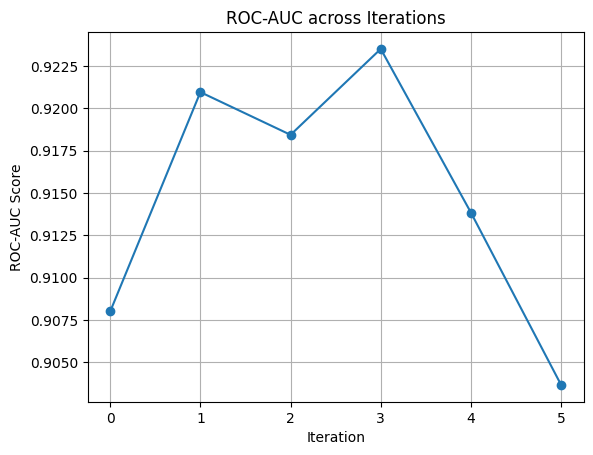

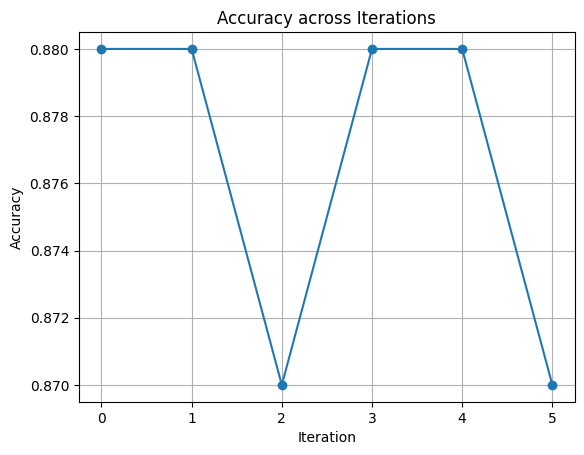

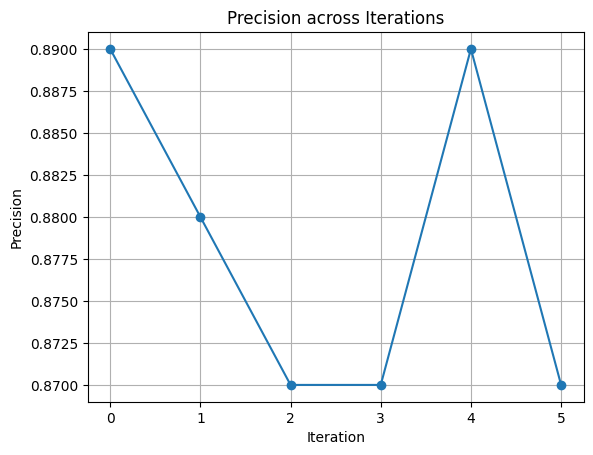

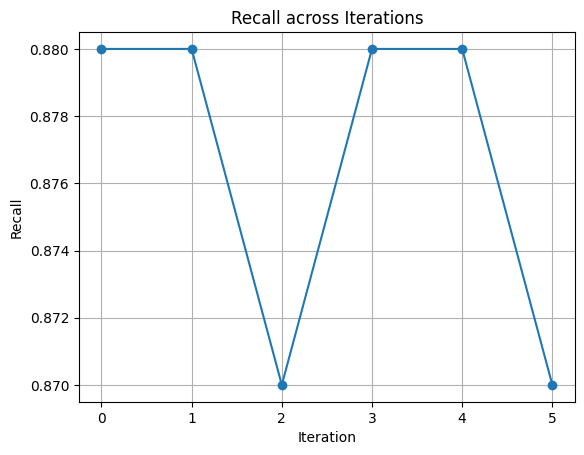

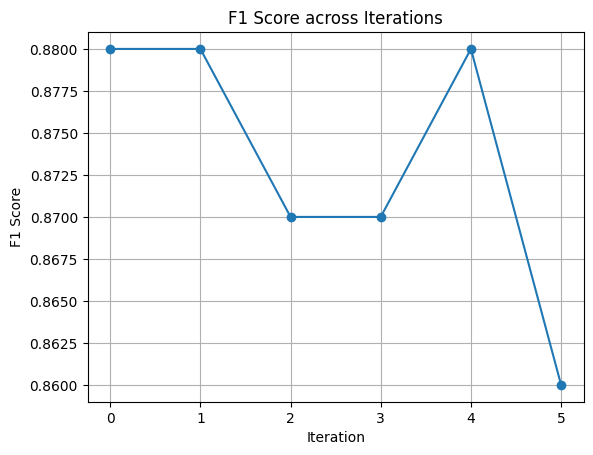

In [38]:
import json
import matplotlib.pyplot as plt

# Load JSON file
file_path = "iteration_logs.json"

with open(file_path, "r") as f:
    data = json.load(f)

# If multiple JSON objects are stored separately, handle like this:
# data = []
# with open(file_path, "r") as f:
#     for line in f:
#         if line.strip():
#             data.append(json.loads(line))

iterations = []
roc_scores = []
accuracies = []
precisions = []
recalls = []
f1_scores = []

print("\n===== CLASSIFICATION REPORTS =====\n")

for item in data:
    it = item["iteration"]
    roc = item["roc_auc"]
    report = item["classification_report"]
    
    acc, prec, rec, f1 = extract_metrics(report)
    
    iterations.append(it)
    roc_scores.append(roc)
    accuracies.append(acc)
    precisions.append(prec)
    recalls.append(rec)
    f1_scores.append(f1)
    
    print(f"\n--- Iteration {it} ---")
    print(f"ROC-AUC: {roc:.4f}")
    print(f"Accuracy: {acc}")
    print(f"Precision: {prec}")
    print(f"Recall: {rec}")
    print(f"F1-score: {f1}")
    print(report)
    
# Plot ROC-AUC graph
plt.figure()
plt.plot(iterations, roc_scores, marker='o')
plt.xlabel("Iteration")
plt.ylabel("ROC-AUC Score")
plt.title("ROC-AUC across Iterations")
plt.grid()

plt.show()

plt.figure()
plt.plot(iterations, accuracies, marker='o')
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.title("Accuracy across Iterations")
plt.grid()
plt.show()

plt.figure()
plt.plot(iterations, precisions, marker='o')
plt.xlabel("Iteration")
plt.ylabel("Precision")
plt.title("Precision across Iterations")
plt.grid()
plt.show()

plt.figure()
plt.plot(iterations, recalls, marker='o')
plt.xlabel("Iteration")
plt.ylabel("Recall")
plt.title("Recall across Iterations")
plt.grid()
plt.show()

plt.figure()
plt.plot(iterations, f1_scores, marker='o')
plt.xlabel("Iteration")
plt.ylabel("F1 Score")
plt.title("F1 Score across Iterations")
plt.grid()
plt.show()